In [8]:
import numpy as np
import pandas as pd
import scanpy as sc
import h5py
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

seed = 123

## Read the pre-processed dataset (see Task 1)

In [11]:
data_dir = '../data/frangieh'
adata = sc.read_h5ad(f"{data_dir}/dataset_hv_tim.h5ad")

## Define functions for clustering (including visualizatino with UMAP) and the required dimensionality reduction

In [12]:
from sklearn.cluster import KMeans
#from sklearn.metrics import adjusted_rand_score

def aggregate_perturbations(adata):
    # Combine all cells with the same perturbation by mean expression value per gene
    treatment = adata.obs.perturbation_2.values[0]
    adata = sc.get.aggregate(adata, by='perturbation', func='mean')
    adata.X = adata.layers['mean'].copy()
    adata.obs['perturbation_2'] = treatment
    return adata

def leiden(adata, resolution=1, title=None):
    sc.tl.leiden(adata, resolution=resolution, flavor='igraph', n_iterations=2, directed=False)
    sc.pl.umap(adata, color='leiden', title=title)

def cl_kmeans(adata, k=8, plot=False, title=None):
    sc.pp.pca(adata, n_comps=50)
    X_pca = adata.obsm['X_pca']
    kmeans = KMeans(n_clusters=k, random_state=seed).fit(X_pca)
    adata.obs['kmeans'] = kmeans.labels_.astype(str)
    if plot:
        sc.pl.umap(adata, color='kmeans', title=title)
    return kmeans

def louvain(adata, resolution=1, title=None):
    sc.tl.louvain(adata, resolution=resolution)
    sc.pl.umap(adata, color='louvain', title=title)

In [13]:
adata_ctl = adata[adata.obs['perturbation_2'].eq('Control')]
adata_ctl = aggregate_perturbations(adata_ctl)

adata_IFN = adata[adata.obs['perturbation_2'].eq('Co-culture')]
adata_IFN = aggregate_perturbations(adata_IFN)

adata_co = adata[adata.obs['perturbation_2'].eq('IFNγ')]
adata_co = aggregate_perturbations(adata_co)

In [14]:
def dim_reduction(adata):
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

In [15]:
dim_reduction(adata_ctl)
dim_reduction(adata_IFN)
dim_reduction(adata_co)

/home/ubuntu/miniforge/envs/sc-course-2026/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Find optimal number of clusters using elbow method

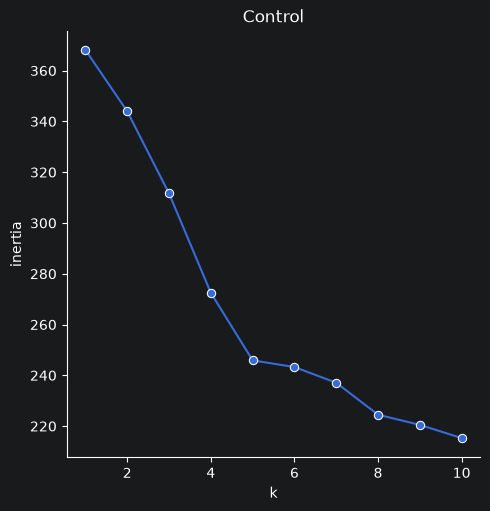

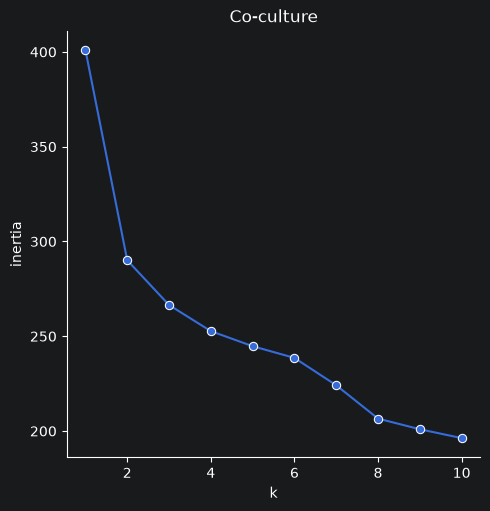

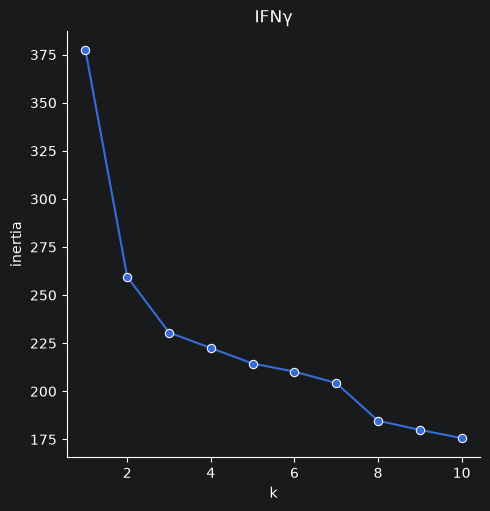

In [16]:
from sklearn.metrics import silhouette_score

for treatment_df in [adata_ctl, adata_IFN, adata_co]:
    inertias = []
    for k in range(1,11):
        kmeans = cl_kmeans(adata=treatment_df, k=k)
        inertias.append(kmeans.inertia_)

    inertias = {
        'k':range(1,11),
        'inertia':inertias,
    }

    sns.relplot(inertias, x='k', y='inertia', kind='line', marker='o')
    plt.title(treatment_df.obs.perturbation_2.values[0])

## Perform clustering (leiden and kmeans) on each condition separately as the cells would cluster strongly by condition otherwise

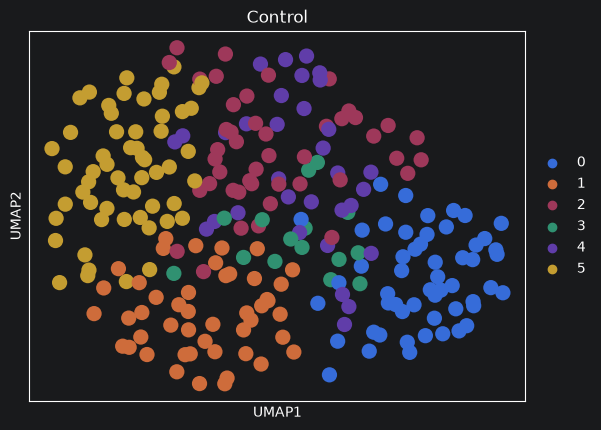

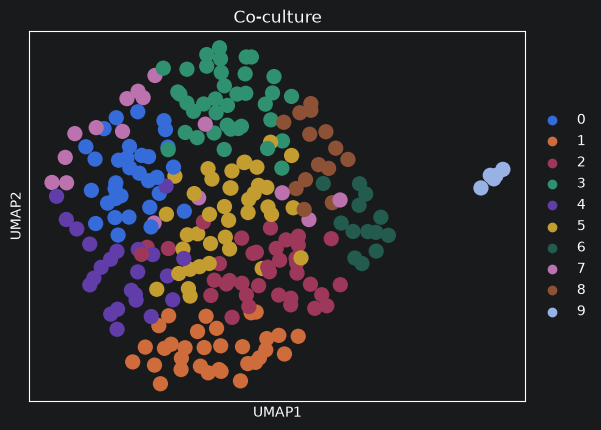

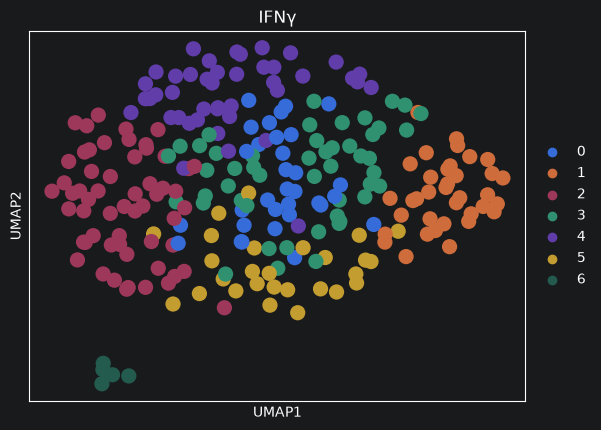

In [17]:
for condition_data in [adata_ctl, adata_IFN, adata_co]:
    leiden(condition_data, 1, condition_data.obs.perturbation_2.values[0])

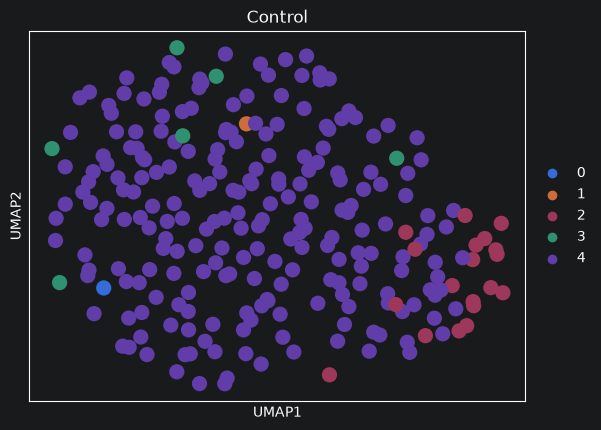

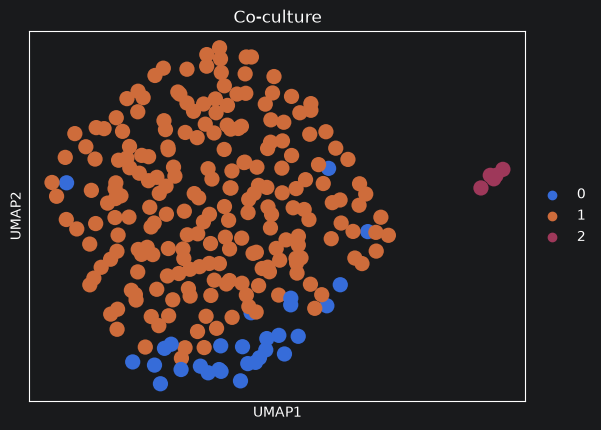

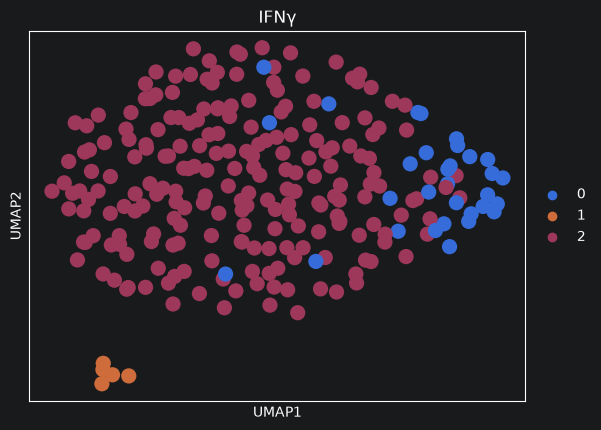

In [18]:
for condition_data, k in [[adata_ctl,5], [adata_IFN,3], [adata_co,3]]:
    cl_kmeans(
        adata=condition_data,
        k=k,
        plot=True,
        title=condition_data.obs.perturbation_2.values[0])

## Evaluate, which perturbations cluster together by treatment condition

In [19]:
# Leiden
for treatment_df in [adata_ctl, adata_IFN, adata_co]:
    print('------------------------------------------------')
    print (treatment_df.obs.perturbation_2.values[0])
    for cluster in treatment_df.obs.leiden.cat.categories:
        print(f'\n\nLeiden #{cluster}')
        data = treatment_df[treatment_df.obs.leiden == cluster].obs
        print(data)

------------------------------------------------
Control


Leiden #0
          perturbation  n_obs_aggregated perturbation_2 kmeans leiden
A2M                A2M               373        Control      4      0
ACSL3            ACSL3               181        Control      4      0
AGA                AGA               317        Control      4      0
AHCY              AHCY                34        Control      2      0
APOD              APOD               301        Control      4      0
B2M                B2M               362        Control      4      0
BOLA2            BOLA2               169        Control      4      0
BOLA2B          BOLA2B               201        Control      4      0
BZW2              BZW2               279        Control      4      0
C19orf48      C19orf48               299        Control      4      0
CCND1            CCND1               201        Control      2      0
CCT3              CCT3                51        Control      2      0
CD63              CD6

In [20]:
# kmeans
for treatment_df in [adata_ctl, adata_IFN, adata_co]:
    print('------------------------------------------------')
    print (treatment_df.obs.perturbation_2.values[0])
    for cluster in treatment_df.obs.kmeans.cat.categories:
        print(f'\n\nk-means #{cluster}')
        data = treatment_df[treatment_df.obs.kmeans == cluster].obs
        print(data)

------------------------------------------------
Control


k-means #0
     perturbation  n_obs_aggregated perturbation_2 kmeans leiden
TUBB         TUBB                 2        Control      0      1


k-means #1
      perturbation  n_obs_aggregated perturbation_2 kmeans leiden
PSMA7        PSMA7                 4        Control      1      4


k-means #2
         perturbation  n_obs_aggregated perturbation_2 kmeans leiden
AHCY             AHCY                34        Control      2      0
CCND1           CCND1               201        Control      2      0
CCT3             CCT3                51        Control      2      0
CDK6             CDK6               109        Control      2      0
CTPS1           CTPS1               114        Control      2      0
EEF1G           EEF1G                46        Control      2      0
FARSA           FARSA                24        Control      2      0
GPI               GPI                48        Control      2      0
ILF2             ILF2

**One noticeable observation:**<br>
JAK/STAT pathway genes (JAK1/2, STAT1, IFNGR1/2) cluster together in IFN and co-culture conditions -> JAK/STAT pathway is compromised which alters gene expression in an environment in which IFN is present.

In [76]:
# modify the code to create plots for each condition (move to function and loop over it for each condition)
# identify clusters with highly enriched perturbations and extract the affected pathways
# lookup the extracted pathways to identify their biological function and compare with the paper

# maybe modify the procedure for matching the perturbations to the clusters and for assigning the cluster scores (this seems to be not very robust -> assigns each perturbation only to one
# cluster even if the perturbation is equally present in two different clusters. 

In [ ]:
# other options for assigning clusters:
# 1. loop over clusters and assign every perturbation to that cluster which is represented by a percentage of the total number of cells with that perturbation over a threshold (30%?)
# -> that way, not all perturbations will be assigned to a cluster, and a perturbation can be assigned to multiple clusters
# then, perturbations that dont cluster well will not be assigned to a cluster at all and perturbations that cluster well but in different clusters (maybe affected by another factor)
# will be present in both clusters -> you can calculate the number of perbs in no cluster and in multiple clusters